## Jose E Rodriguez Rios
## Variable:Mental health


In [217]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import sklearn.linear_model as skl
from scipy import stats

In [218]:
#suicide dataset from https://wonder.cdc.gov/
suicidesWonder = pd.read_csv('../data/suicide/SuicidesWonder.csv',sep='\t')


In [219]:
suicidesWonder = suicidesWonder.drop(columns=['Notes', 'Population','Crude Rate'])





In [220]:
suicidesWonder['month'] = pd.to_datetime(suicidesWonder['Month Code']).dt.month_name()

In [221]:
suicidesWonder.rename(columns = {'Year':'year','State':'state'}, inplace = True)

In [222]:
suicidesWonder['year'] = suicidesWonder['year'].astype(str)
suicidesWonder['state'] = suicidesWonder['state'].astype(str)
suicidesWonder['month'] = suicidesWonder['month'].astype(str)


In [223]:
# Consumer Price Index from bureau of labor https://www.bls.gov/cpi/data.htm
inflation = pd.DataFrame(pd.read_csv("../data/inflation/CPI.csv"))

In [224]:
inflation=inflation[10:]

In [225]:
inflation.columns=inflation.iloc[0]

In [226]:
inflation=inflation[1:]

In [227]:
inflation.rename(columns = {'Year':'year'}, inplace = True)

In [228]:
inflation = inflation.melt(id_vars=['year'], var_name='month', value_name='Value')

In [229]:
inflation_suicide = pd.merge(inflation, suicidesWonder, how='inner', on=['year','month'])

In [230]:
inflation_suicide[ 'Month'] = inflation_suicide['month'].apply(lambda x: datetime.strptime(x, '%B').month)

In [231]:
inflation_suicide['Date'] = pd.to_datetime(inflation_suicide[['year', 'Month']].assign(day=1))

In [232]:
inflation_suicide = inflation_suicide.sort_values('Date')

In [233]:
suicides_grouped = suicidesWonder.groupby('year')['Deaths'].sum().reset_index()

In [234]:
inflation_suicide_yearly = pd.merge(inflation, suicides_grouped, how='inner', on=['year'])

In [235]:
inflation_suicide_yearly['Deaths'] = inflation_suicide_yearly['Deaths'].astype(float)
inflation_suicide_yearly['Value'] = inflation_suicide_yearly['Value'].astype(float)


In [236]:
correlation = inflation_suicide_yearly['Deaths'].corr(inflation_suicide_yearly['Value'])

In [237]:
#plt.plot(inflation_suicide_yearly['year'], inflation_suicide_yearly['Deaths'], label='Number of Suicides')


In [238]:
#plt.plot(inflation_suicide_yearly['year'], inflation_suicide_yearly['Value'], label='Inflation Rate')


# Suicides cases reported up to a year


In [239]:
#Question Cases Suicides reported up to a year

suicides_grouped


,year,Deaths
0,1999,28972
1,2000,29047
2,2001,30269
3,2002,31266
4,2003,31138
5,2004,32053
6,2005,32248
7,2006,32962
8,2007,34221
9,2008,35733


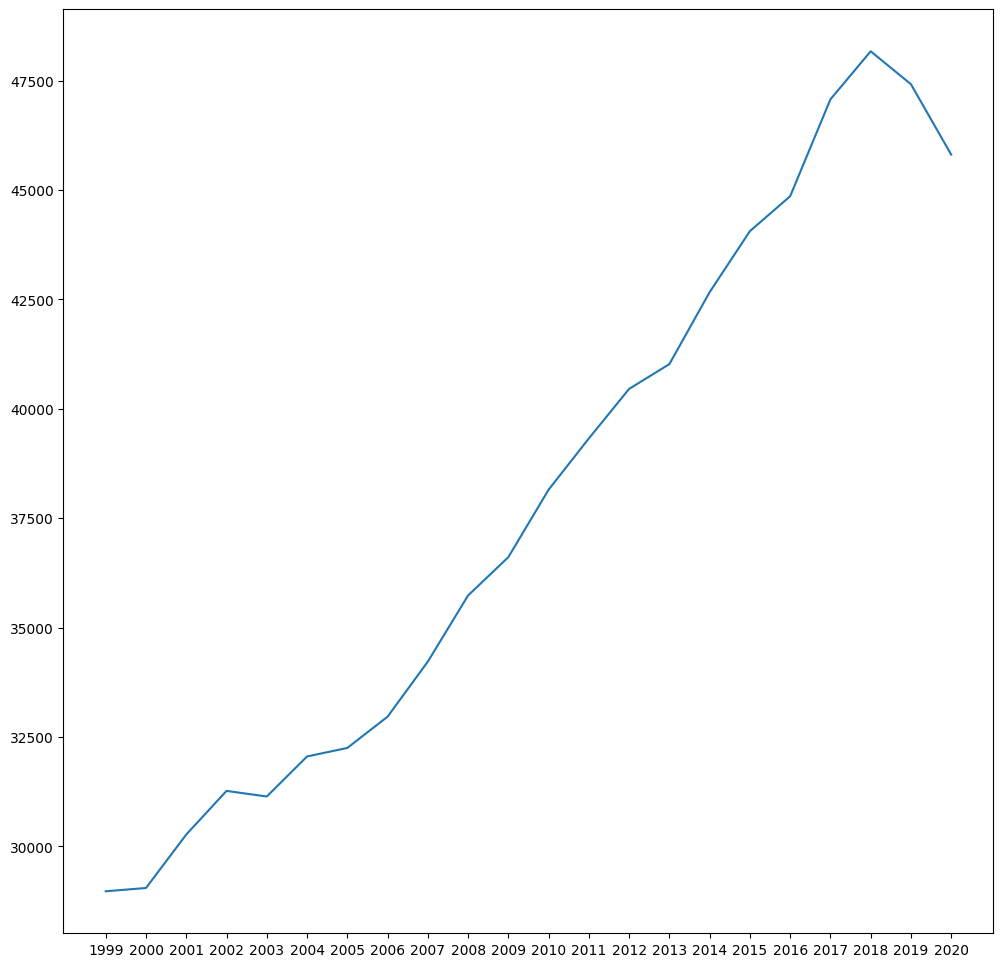

In [240]:
plt.figure(figsize=(12,12))

plt.plot(suicides_grouped['year'], suicides_grouped['Deaths'], label='Number of Suicides')


In [241]:
# Results: suicide count
## Seems like from the data shown suicide as the years go by is always increasing

# Number of suicides because of inflation


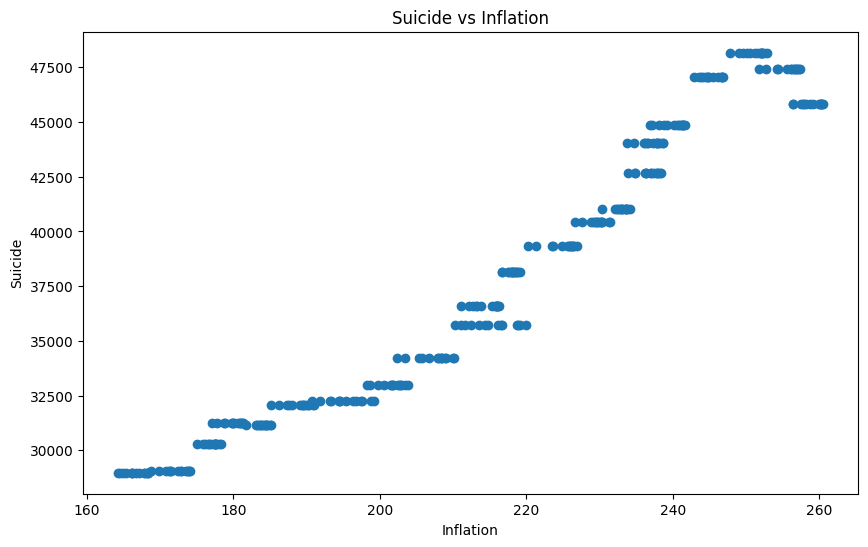

In [242]:

plt.figure(figsize=(10,6))
plt.scatter(inflation_suicide_yearly['Value'], inflation_suicide_yearly['Deaths'])
plt.title('Suicide vs Inflation')
plt.xlabel('Inflation')
plt.ylabel('Suicide')
plt.show()


In [243]:
correlation = inflation_suicide_yearly['Value'].corr(inflation_suicide_yearly['Deaths'])
print(f"The correlation between inflation and deaths is {correlation}")


The correlation between inflation and deaths is 0.9744195044209996


# Outcomes: Correlation Between Suicide and Inflation
## The preceding analysis, involving a scatter plot and correlation calculation, revealed a significant association between the number of deaths and respective inflation rates. A robust correlation coefficient of 0.9744 suggests a high degree of interdependence, thereby hinting that inflation could indeed influence suicide rates.



# SKlearn model to predict future values

In [244]:
Deaths=inflation_suicide_yearly['Deaths']

In [245]:
inflation=inflation_suicide_yearly['Value']

221.29267506474207

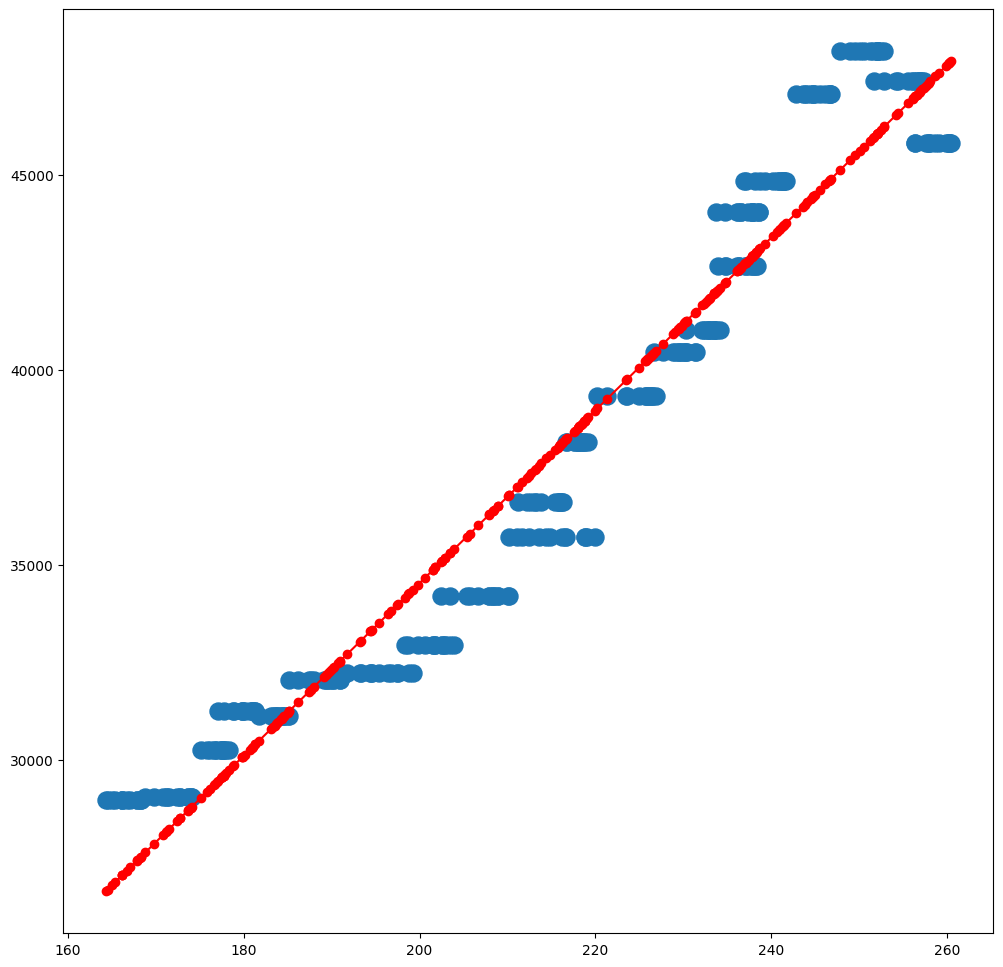

In [246]:

model = skl.LinearRegression()
x = inflation.values.reshape(-1,1)
model.fit(x, Deaths)
y_pred = model.predict(x)
plt.figure(figsize=(12,12))

plt.scatter(x, Deaths, marker ='.', s= 600)
plt.plot(x, y_pred, "r-o")
model.score(x,Deaths)
model.coef_[0]

# Model results
## According to the model, an inflation coefficient of 221.29267506474207 indicates that for every unit uptick in inflation, the model anticipates a rise in suicides by approximately 221.3, provided that all other influencing factors remain unchanged."

# Conclusion
## Based on the outcomes of these analyses, it appears that a significant correlation exists between mental health and the economy. Evidence suggests that as inflation rates rise, the incidence of suicides tends to increase as well."